Flight Price Prediction

In [57]:
# ==========================
# Import Libraries
# ==========================

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date and Time
from datetime import datetime

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Machine Learning - Data Splitting
from sklearn.model_selection import train_test_split, cross_val_score, KFold

# Machine Learning - Preprocessing
from sklearn.preprocessing import LabelEncoder

# Machine Learning - Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)


# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Model Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

# Model Saving
import pickle



Load data

In [58]:
df = pd.read_excel("Flight_Fare.xlsx")
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


Exploratory Data Analysis

In [59]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [60]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [61]:
df.shape

(10683, 11)

Missing Values

In [62]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

Duplicate Records

In [63]:
df.duplicated().sum()

np.int64(220)

df[df.duplicated()]

Univariate Analysis</br>
Airline distribution</br>
Source distribution</br>
Destination distribution</br>
Price distribution

<Axes: xlabel='Price', ylabel='Count'>

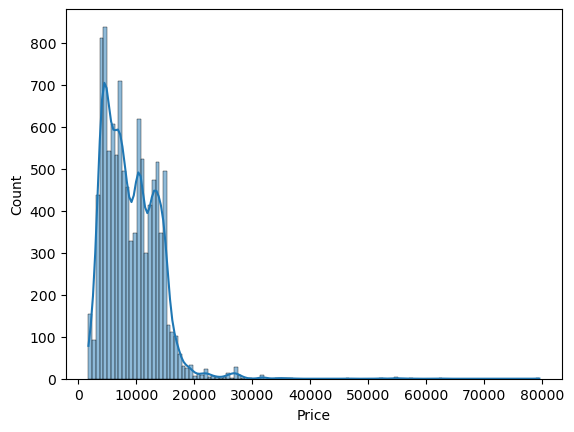

In [64]:
sns.histplot(df['Price'], kde=True)

Bivariate Analysis</br>
Airline vs Price

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'IndiGo'),
  Text(1, 0, 'Air India'),
  Text(2, 0, 'Jet Airways'),
  Text(3, 0, 'SpiceJet'),
  Text(4, 0, 'Multiple carriers'),
  Text(5, 0, 'GoAir'),
  Text(6, 0, 'Vistara'),
  Text(7, 0, 'Air Asia'),
  Text(8, 0, 'Vistara Premium economy'),
  Text(9, 0, 'Jet Airways Business'),
  Text(10, 0, 'Multiple carriers Premium economy'),
  Text(11, 0, 'Trujet')])

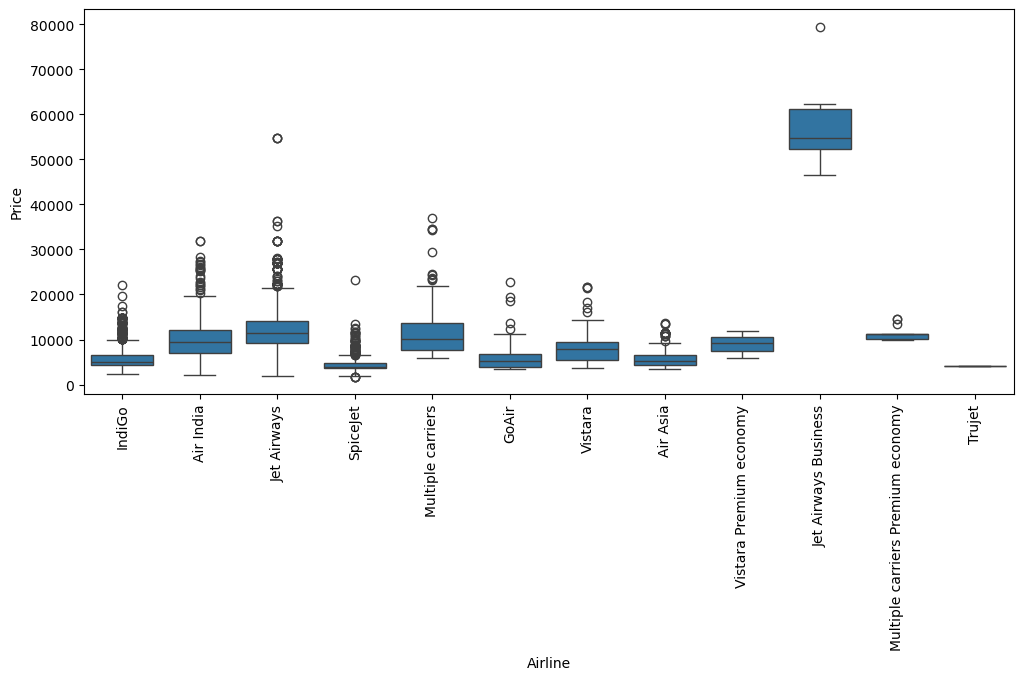

In [65]:
plt.figure(figsize=(12,5))
sns.boxplot(x='Airline', y='Price', data=df)
plt.xticks(rotation=90)

Total Stops vs Price

<Axes: xlabel='Total_Stops', ylabel='Price'>

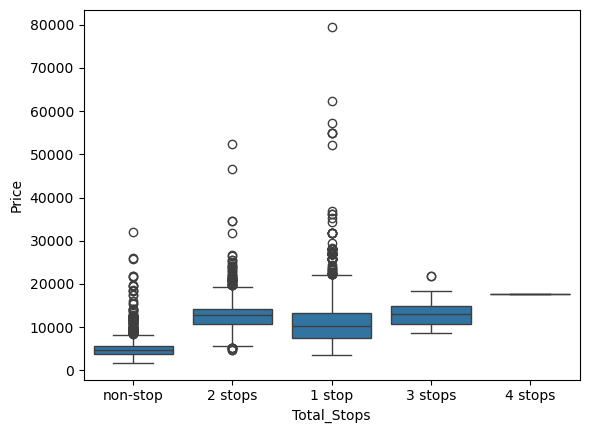

In [66]:
sns.boxplot(x='Total_Stops', y='Price', data=df)

Source vs Price

<Axes: xlabel='Source', ylabel='Price'>

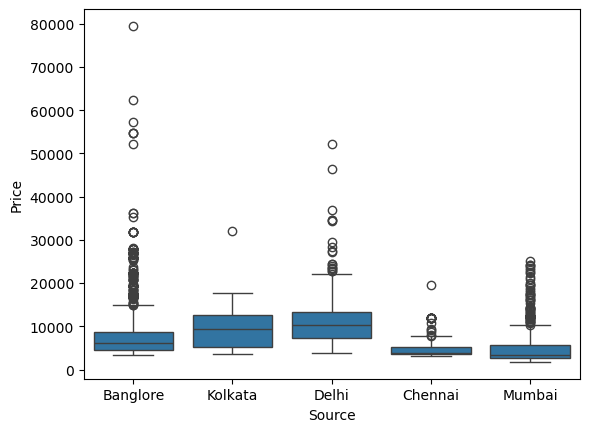

In [67]:
sns.boxplot(x='Source', y='Price', data=df)

Correlation Analysis

<Axes: >

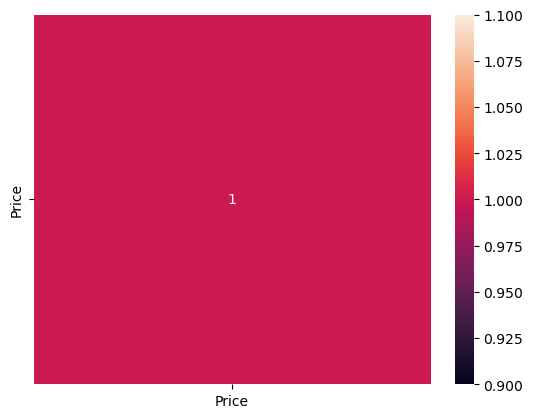

In [68]:
import seaborn as sns

# Filter only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['number'])

# Create heatmap with only numeric columns
sns.heatmap(numeric_df.corr(), annot=True)

Data Preprocessing</br>
Handling Missing Values

In [69]:
df.dropna(inplace=True)

In [70]:
df.shape

(10682, 11)

Date Feature Extraction

In [71]:
df["Journey_day"] = pd.to_datetime(df.Date_of_Journey).dt.day

df["Journey_month"] = pd.to_datetime(df.Date_of_Journey).dt.month

df.drop("Date_of_Journey", axis=1, inplace=True)

Departure Time

In [72]:
df["Dep_hour"] = pd.to_datetime(df["Dep_Time"]).dt.hour
df["Dep_min"] = pd.to_datetime(df["Dep_Time"]).dt.minute

df.drop("Dep_Time", axis=1, inplace=True)

Arrival Time

In [73]:
df["Arrival_hour"] = pd.to_datetime(df["Arrival_Time"]).dt.hour
df["Arrival_min"] = pd.to_datetime(df["Arrival_Time"]).dt.minute

df.drop("Arrival_Time", axis=1, inplace=True)

Duration Conversion

In [74]:
duration = list(df["Duration"])

for i in range(len(duration)):
    if len(duration[i].split()) != 2:
        if "h" in duration[i]:
            duration[i] = duration[i] + " 0m"
        else:
            duration[i] = "0h " + duration[i]

#df["Duration_hours"] = duration_hours
#df["Duration_mins"] = duration_mins


Total Stops Encoding

In [75]:
df.replace({"non-stop":0,
            "1 stop":1,
            "2 stops":2,
            "3 stops":3,
            "4 stops":4},
           inplace=True)

Categorical Encoding
One Hot Encoding

In [76]:
Airline = pd.get_dummies(df['Airline'], drop_first=True)

Source = pd.get_dummies(df['Source'], drop_first=True)

Destination = pd.get_dummies(df['Destination'], drop_first=True)

Remove Unnecessary Columns

In [77]:
df.drop(['Route','Additional_Info'], axis=1, inplace=True)

Outlier Detection

In [78]:
# Features (independent variables)
X = df.drop('Price', axis=1)

# Target (dependent variable)
y = df['Price']

<Axes: ylabel='Price'>

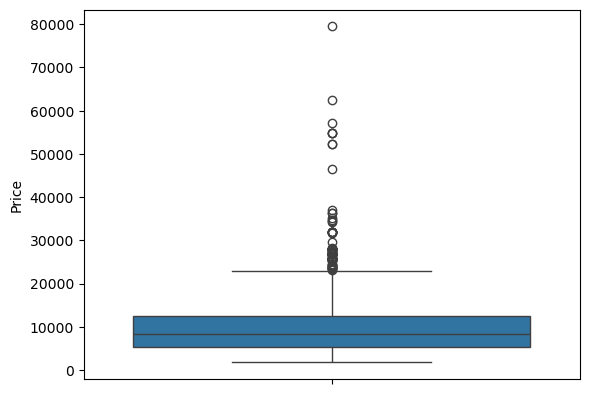

In [79]:
sns.boxplot(df['Price'])

IQR Method

In [80]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

Feature Selection

In [81]:
from sklearn.ensemble import ExtraTreesRegressor

model = ExtraTreesRegressor()
model.fit(X,y)

feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh')

ValueError: could not convert string to float: 'IndiGo'

Model Building

Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)

Models to Compare

Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor

Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

Extra Trees Regressor

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor

Evaluation Metrics

In [ ]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [ ]:
from sklearn.metrics import r2_score

# Predict on test data
y_pred = model.predict(X_test)

# Calculate R² Score
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

In [ ]:
print(X.shape)
print(y.shape)

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor

model = ExtraTreesRegressor(random_state=42)

model.fit(X, y)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feat_importances = pd.Series(model.feature_importances_, index=X.columns)

feat_importances.nlargest(20).plot(kind='barh', figsize=(8,6))
plt.title("Top 20 Feature Importances")
plt.show()

In [ ]:
df.columns

In [ ]:
df.info()